In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.io as sio
from sklearn.metrics import roc_auc_score as auROC
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
import copy
import math
import importlib
import common_func
import plot_utils

importlib.reload(common_func)
importlib.reload(plot_utils)
from common_func import (
    central_tendency,
    standardize_plot_graphics,
    getCumsumChangePoint,
    produce_df_for_all_data,
    produce_data_per_session,
    accumulative_lick_trial_by_trial,
    get_changepoint_params,
    get_df_ind,
    produce_data_df_ind,
    produce_data_per_session_ind,
    )
from plot_utils import (
    plot_evolution_over_learning,
    plot_cumlick_tbt,
    plot_individual_animal_cumlick,
    plot_changepoint,
    plot_ave_psth_overlay_days,
    plot_evolution_over_learning_ind,
    plot_cumlick_ind,
    plot_statistical_differences_to_CSminus,
)

c:\Users\mzhou9\Anaconda3\envs\py3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:7: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,
c:\Users\mzhou9\Anaconda3\envs\py3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:7: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,


## Individual animal data analysis

In [2]:
main_data_dir = r"C:\Users\mzhou9\OneDrive - UCSF\2p\MZ_CA1_WD_F5"
num_days = 24
cue_types = ["CS1", "CS2", "CS3"]
# result_dir = os.path.join(main_data_dir, "behavioral result")
# if not os.path.exists(result_dir):
#     os.makedirs(result_dir)

alldata = produce_data_df_ind(main_data_dir, num_days)
sessiondata = produce_data_per_session_ind(alldata, num_days)
# print(sessiondata)

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
C:\Users\mzhou9\AppData\Local\Temp\1/ipykernel_33800/434907178.py:5: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_lick_diff_to_csminus.show()


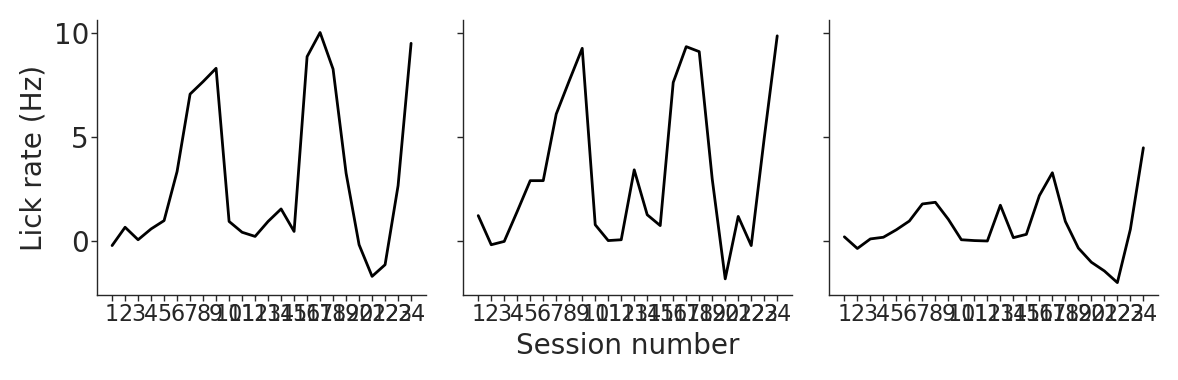

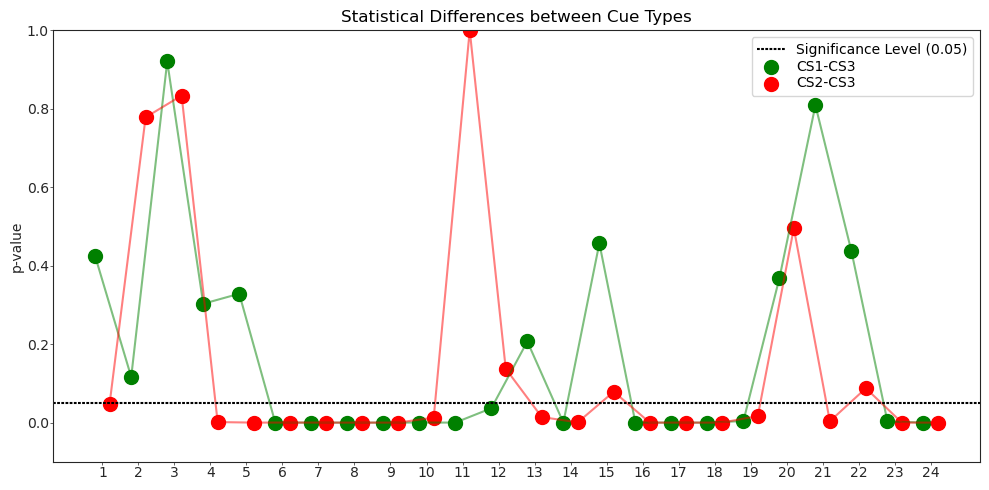

In [6]:
fig_learning_evolution = plot_evolution_over_learning_ind(sessiondata, cue_types, num_days)
# fig_learning_evolution.savefig(os.path.join(result_dir, "learning_evolution.png"), format="png")

fig_lick_diff_to_csminus, results = plot_statistical_differences_to_CSminus(alldata, cue_types=cue_types, num_days=num_days)
fig_lick_diff_to_csminus.show()

## Group data analysis

In [3]:
main_data_dir = r"Z:\2p\experiment1\population behavioral data"
cue_types = ["CS1", "CS2", "CS3"]
numtrials = [25, 25, 50]
num_days = 10
colors = {'ave':'#292828', 'ind':'#808080'}
result_dir = os.path.join(main_data_dir, "results")
if not os.path.exists(result_dir):
    os.makedirs(result_dir)
    
alldata, psth = produce_df_for_all_data(main_data_dir)
sessiondata = produce_data_per_session(alldata, num_days)

MZ_CA1_WD_F3
MZ_CA1_WD_JB_54
MZ_CA1_WD_JB_55
MZ_CA1_WD_M6
MZ_CA1_WD_M7
MZ_CA1_WD_M8


findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.


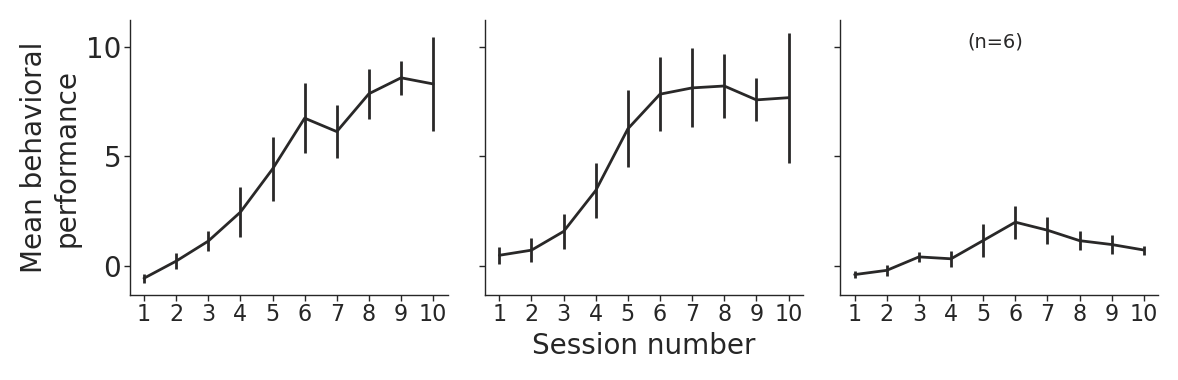

In [4]:
fig_learning_evolution, _ = plot_evolution_over_learning(sessiondata, cue_types, colors, 10)
fig_learning_evolution.savefig(
        os.path.join(result_dir, "initiallearning.svg"), format="svg"
    )

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.


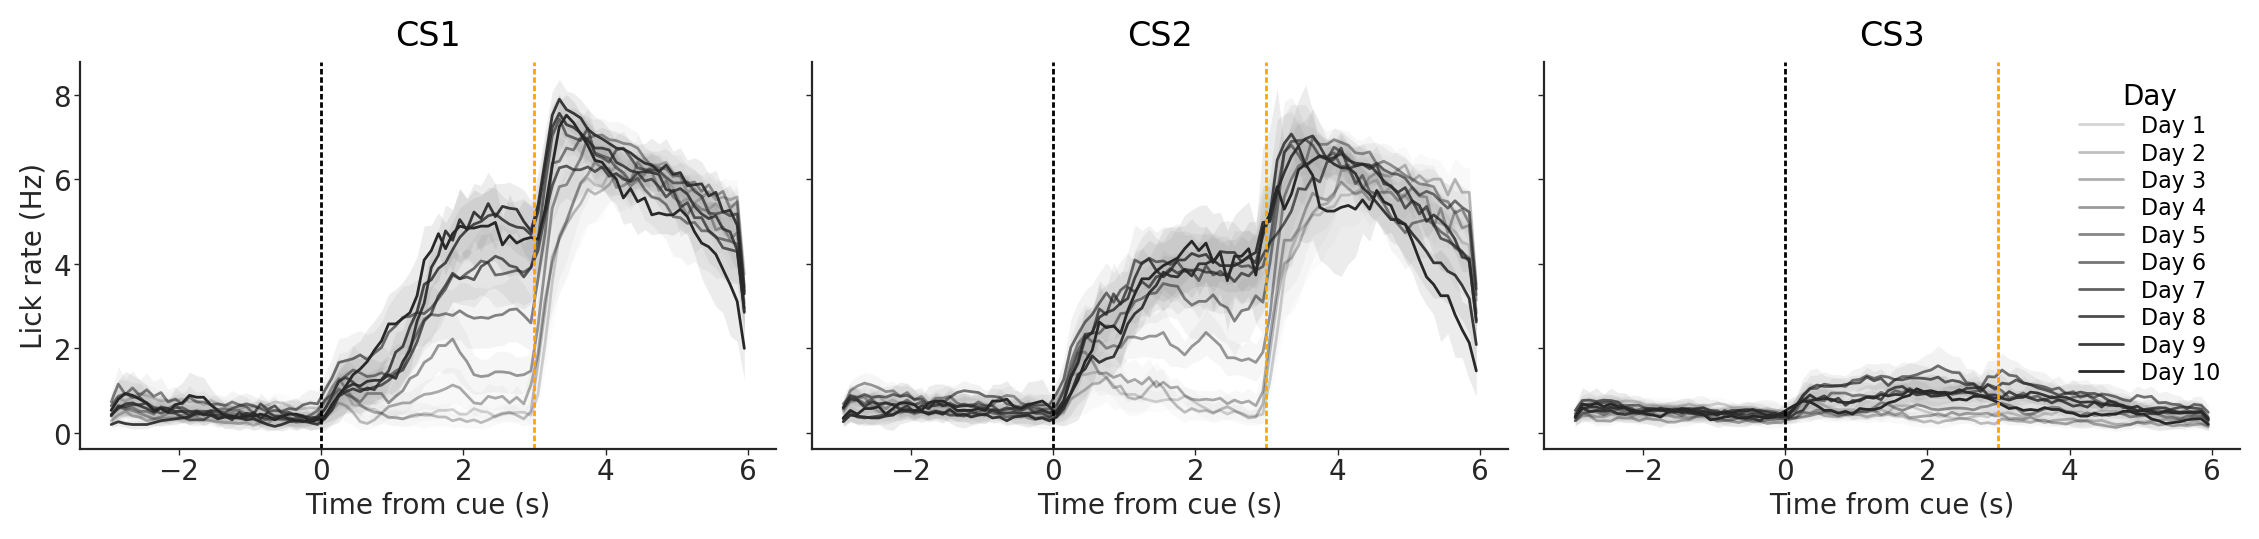

In [5]:
fig_PSTH, _ = plot_ave_psth_overlay_days(
    psth,
    cue_types,
    colors=colors,
    row_mode="Day",
    row_values=np.arange(1, num_days+1).tolist(),  # or None to infer
    smooth_bins=3,
)
fig_PSTH.savefig(
        os.path.join(result_dir, "PSTH_overlay.svg"), format="svg"
    )
fig_PSTH.savefig(
        os.path.join(result_dir, "PSTH_overlay.png"), format="png"
    )

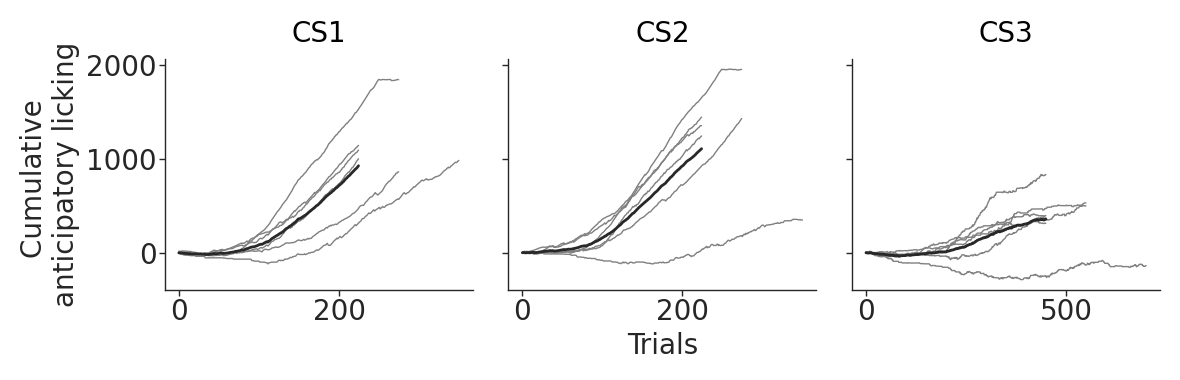

In [74]:
cumdata = accumulative_lick_trial_by_trial(alldata, cue_types, numtrials, animals_to_remove=[])
fig_cumlick = plot_cumlick_tbt(cumdata, cue_types, colors, num_days, numtrials)
fig_cumlick.savefig(
        os.path.join(result_dir, "cumlick_tbt.svg"), format="svg"
    )

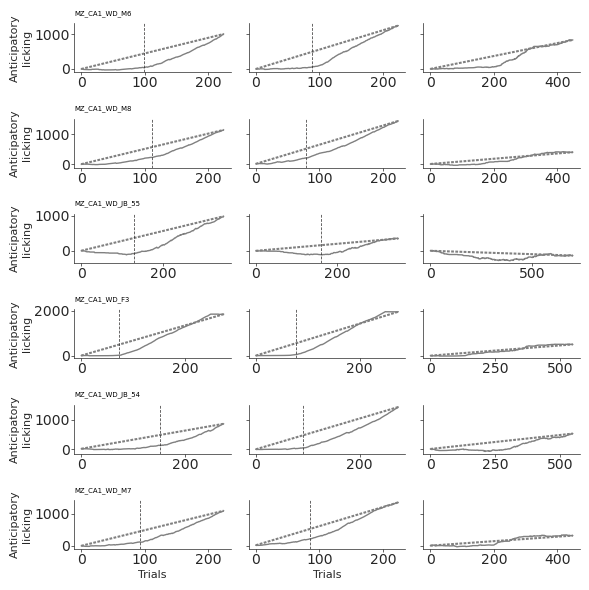

In [75]:
changepoint_threshold = 0.95
abruptness, learnedtrial, meanslope = get_changepoint_params(cumdata, cue_types, changepoint_threshold)
fig_ind_animals = plot_individual_animal_cumlick(
    cumdata, learnedtrial, cue_types, colors)
# plt.close(fig_ind_animals)
fig_ind_animals.savefig(
    os.path.join(result_dir, "individual_animal_cumlick.svg"), format="svg"
)

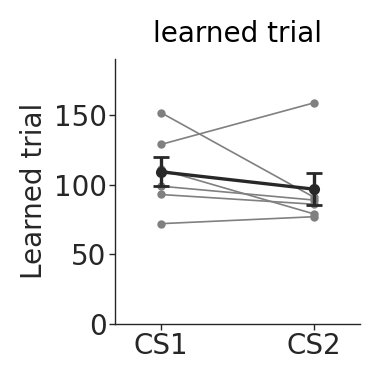

In [76]:
fig_learnedtrial = plot_changepoint(learnedtrial, cue_types[:2], colors, "learned trial")
fig_learnedtrial.savefig(os.path.join(result_dir, "learned_trial.svg"), format="svg")

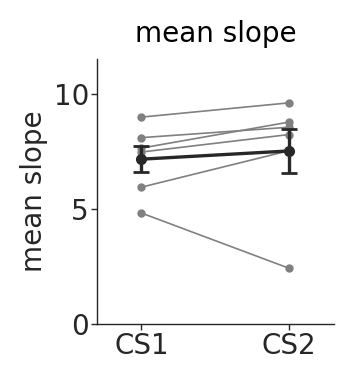

In [77]:
fig_meanslope = plot_changepoint(meanslope, cue_types[:2], colors, "mean slope")
fig_meanslope.savefig(os.path.join(result_dir, "mean_slope.svg"), format="svg")